LSTM Model (Univariat)

Train length: 1400
Test length : 381
X_train shape: (1360, 30, 1)
X_test shape : (381, 30, 1)
Using device: cpu
Epoch 1/50 - Train Loss: 0.036363
Epoch 10/50 - Train Loss: 0.011286
Epoch 20/50 - Train Loss: 0.008657
Epoch 30/50 - Train Loss: 0.007023
Epoch 40/50 - Train Loss: 0.006924
Epoch 50/50 - Train Loss: 0.006759

--- METRIKEN (PyTorch LSTM mit Feiertags-Adjust) ---
MSE          : 14176620.91
RMSE         : 3765.19
R²           : 0.6410
MAE          : 2790.54
Relative MSE : 0.3944
MAPE         : 26.80%


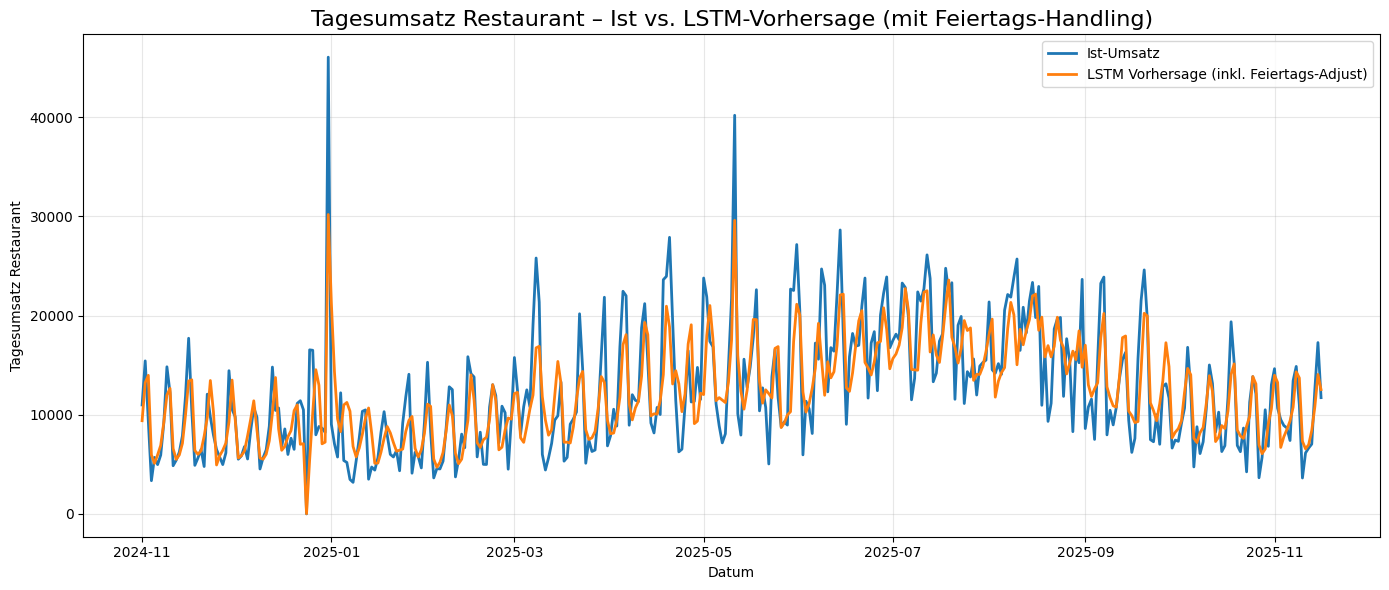

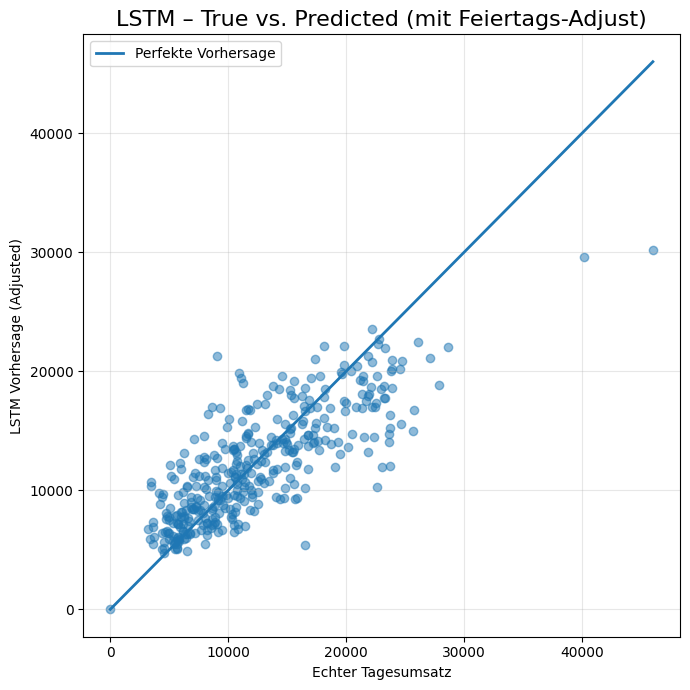

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)

#Daten laden & vorbereiten

df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Univariate Zeitreihe
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# tägliche Frequenz & Lücken füllen
ts = ts.asfreq("D")
ts = ts.ffill().bfill()

# df_full für holiday_average_last_3_years (mit Datum-Spalte & daily-Frequenz)
df_full = ts.reset_index().rename(columns={"Datum": "Datum"})
target_col = "Tagesumsatz Restaurant"

# Train/Test-Split
split_date = pd.Timestamp("2024-11-01")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# Skaler nur auf Train anpassen
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

# gesamte Serie mit demselben Skaler transformieren
full_scaled = scaler.transform(ts.values.reshape(-1, 1)).flatten()
dates = ts.index

#Sliding-Window-Datensatz (Feiertage aus TRAIN entfernen)

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
dates_test = []

for i in range(window_size, len(full_scaled)):
    X_seq = full_scaled[i - window_size:i]
    y_target = full_scaled[i]
    target_date = dates[i]

    if target_date < split_date:
        # Feiertage im TRAINING entfernen (Weihnachten, Silvester, Muttertag)
        if is_special_day(target_date):
            continue
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    else:
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

# LSTM-Input: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

#PyTorch Dataset & DataLoader 

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

#LSTM-Modell definieren 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#Training 

epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Train Loss: {epoch_loss:.6f}")

#Vorhersage auf Testset 

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Feiertags-Adjust (24.12., 31.12., Muttertag) 

y_pred_adjusted = y_pred.copy()

for i, d in enumerate(dates_test):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target_col
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target_col
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df_full,
            date_func=mothers_day,
            year=year,
            target_col=target_col
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# Metriken 

mse  = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred_adjusted)
mae  = mean_absolute_error(y_test, y_pred_adjusted)

# naive Baseline: Vortag
ts_shifted = ts.shift(1)
y_naive = ts_shifted.loc[dates_test].values
y_naive = pd.Series(y_naive, index=dates_test).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred_adjusted)

print("\n--- METRIKEN (PyTorch LSTM mit Feiertags-Adjust) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# Plots 

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label="Ist-Umsatz", linewidth=2)
plt.plot(dates_test, y_pred_adjusted, label="LSTM Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage (mit Feiertags-Handling)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_adjusted, alpha=0.5)

min_val = min(y_test.min(), y_pred_adjusted.min())
max_val = max(y_test.max(), y_pred_adjusted.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted (mit Feiertags-Adjust)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage (Adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


LSTM Model with Features

Feature-Spalten: ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)', 'Tagesumsatz Restaurant']
Zielvariable   : Tagesumsatz Restaurant
Train length (Tage): 1400
Test length  (Tage): 381
X_train shape: (1360, 30, 8)
X_test shape : (381, 30, 8)
Anzahl Features: 8
Using device: cpu
Epoch 1/50 - Train Loss: 0.032235
Epoch 10/50 - Train Loss: 0.006973
Epoch 20/50 - Train Loss: 0.006101
Epoch 30/50 - Train Loss: 0.006064
Epoch 40/50 - Train Loss: 0.005323
Epoch 50/50 - Train Loss: 0.005080

--- METRIKEN (PyTorch LSTM mit Features & Feiertags-Adjust) ---
MSE          : 14903799.57
RMSE         : 3860.54
R²           : 0.6226
MAE          : 2833.33
Relative MSE : 0.4147
MAPE         : 23.65%


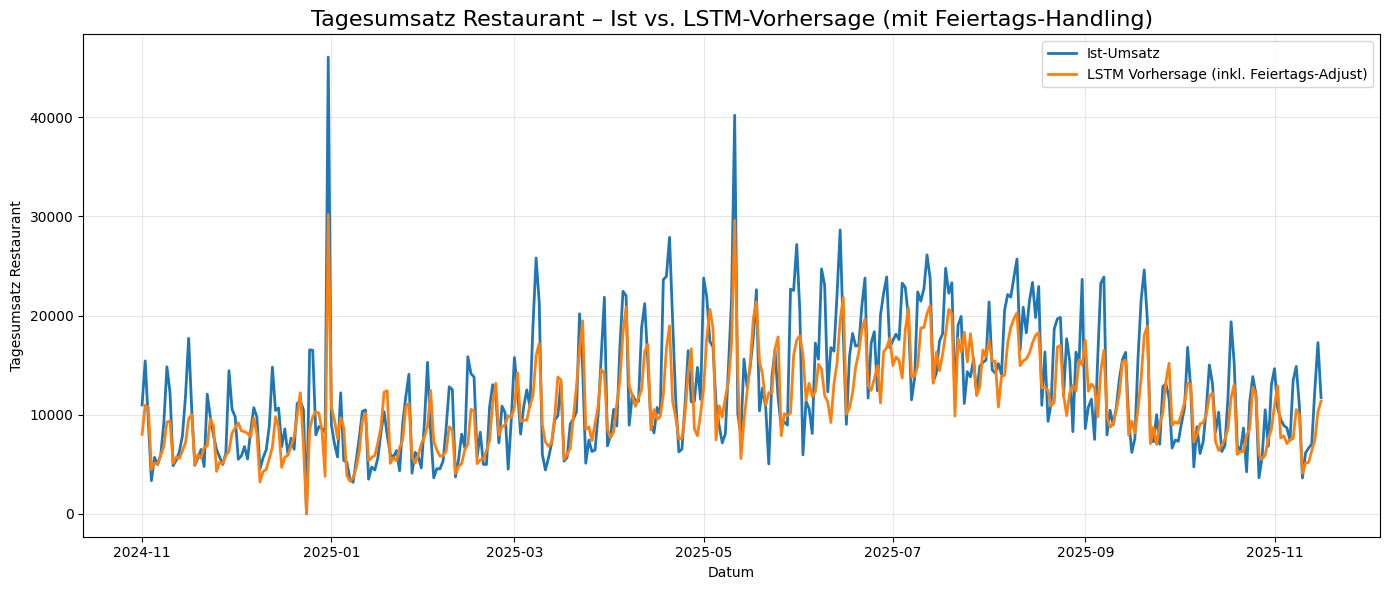

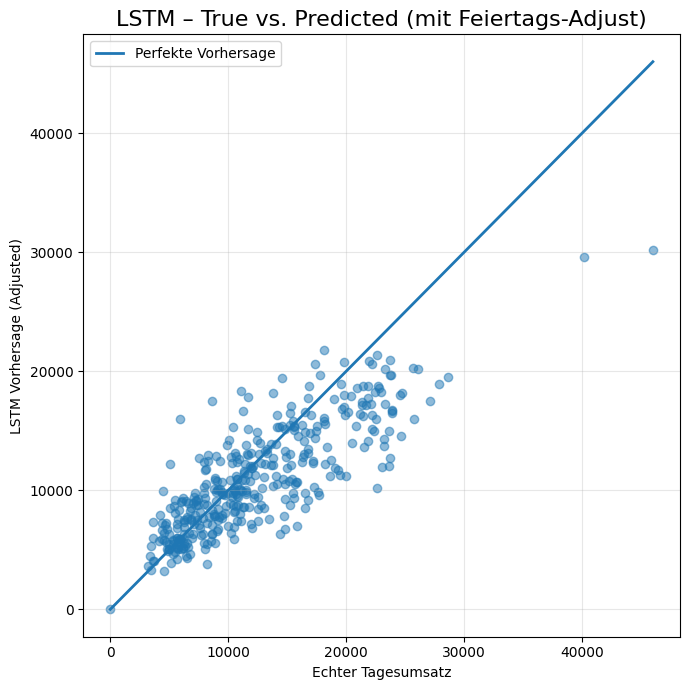


Weihnachten im Testset (24.12.):


,Datum,Ist,Vorhersage
53,2024-12-24,8.6,24.866667



Silvester im Testset (31.12.):


,Datum,Ist,Vorhersage
60,2024-12-31,46032.2,30177.767578



Muttertag im Testset:


,Datum,Ist,Vorhersage
191,2025-05-11,40176.1,29589.666016


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)

# Daten laden & Grund-Preprocessing 

df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Umsatzbestandteile entfernen (sonst Data Leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

target_col = "Tagesumsatz Restaurant"

# Index setzen, tägliche Frequenz & Lücken füllen
df = df.set_index("Datum").asfreq("D")
df = df.ffill().bfill()

# df_full mit Datum-Spalte für holiday_average_last_3_years
df_full = df.reset_index().copy()  # enthält Spalte 'Datum' + daily-Frequenz

# Nur numerische Spalten als potenzielle Features
num_cols = df.select_dtypes(include=["number"]).columns

# Feature-Spalten = alle numerischen Spalten (inkl. Ziel, wir trennen y nur im Scaler)
feature_cols = list(num_cols)

print("Feature-Spalten:", feature_cols)
print("Zielvariable   :", target_col)

# Train/Test-Split anhand Datum
split_date = pd.Timestamp("2024-11-01")
train_df = df[df.index < split_date]
test_df  = df[df.index >= split_date]

print("Train length (Tage):", len(train_df))
print("Test length  (Tage):", len(test_df))

# Skalierung

# X-Scaler: alle Features
scaler_X = MinMaxScaler()
X_train_raw = train_df[feature_cols].values
scaler_X.fit(X_train_raw)

X_all_scaled = scaler_X.transform(df[feature_cols].values)

# y-Scaler: nur Zielvariable
scaler_y = MinMaxScaler()
y_train_raw = train_df[[target_col]].values
scaler_y.fit(y_train_raw)

y_all_scaled = scaler_y.transform(df[[target_col]].values).flatten()

dates = df.index

# Sliding-Window-Datensatz (Feiertage aus TRAIN entfernen) 

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
dates_test = []

n_samples = len(df)

for i in range(window_size, n_samples):
    # Sequenz der Features der letzten window_size Tage
    X_seq = X_all_scaled[i - window_size:i, :]     # (window_size, n_features)
    # Ziel: Zielvariable am Tag i (skaliert)
    y_target = y_all_scaled[i]
    target_date = dates[i]

    if target_date < split_date:
        # Feiertage aus dem TRAINING entfernen
        if is_special_day(target_date):
            continue  # diese Trainings-Observation NICHT verwenden
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    else:
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

n_features = X_train.shape[2]

print("X_train shape:", X_train.shape)  # (N_train, 30, n_features)
print("X_test shape :", X_test.shape)   # (N_test, 30, n_features)
print("Anzahl Features:", n_features)

# PyTorch Dataset & DataLoader 

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

# LSTM-Modell definieren 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor(input_size=n_features).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training 

epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Train Loss: {epoch_loss:.6f}")

# Vorhersage auf Testset 

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala (nur Zielvariable)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Feiertags-Adjust wie bei Linearer Regression 

y_pred_adjusted = y_pred.copy()
test_dates = dates_test  # np.array von Timestamps

for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df_full,                      # daily Daten mit 'Datum'-Spalte
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target_col
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target_col
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df_full,
            date_func=mothers_day,
            year=year,
            target_col=target_col
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# Metriken 

mse  = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred_adjusted)
mae  = mean_absolute_error(y_test, y_pred_adjusted)

# naive Baseline: Vortag (auf Originalskala)
ts = df[target_col]            # vollständige Serie des Ziels
ts_shifted = ts.shift(1)
y_naive = ts_shifted.loc[test_dates].values
y_naive = pd.Series(y_naive, index=test_dates).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred_adjusted)

print("\n--- METRIKEN (PyTorch LSTM mit Features & Feiertags-Adjust) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# Plots 

results = pd.DataFrame({
    "Datum": test_dates,
    "Ist": y_test,
    "Vorhersage": y_pred_adjusted
}).sort_values("Datum")

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"],
         label="LSTM Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage (mit Feiertags-Handling)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(results["Ist"], results["Vorhersage"], alpha=0.5)

min_val = min(results["Ist"].min(), results["Vorhersage"].min())
max_val = max(results["Ist"].max(), results["Vorhersage"].max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted (mit Feiertags-Adjust)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage (Adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: explizit Feiertage im Testset anzeigen
print("\nWeihnachten im Testset (24.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 24)])

print("\nSilvester im Testset (31.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 31)])

print("\nMuttertag im Testset:")
results_mothers = results[results["Datum"].apply(lambda d: d == mothers_day(d.year))]
display(results_mothers)


In [ ]:

# CROSS VALIDATION: Expanding Window für LSTM


horizon_days = 7
min_train_days = 365

dates_all = df.index.unique()
cv_results = []

start_index = min_train_days

while start_index + horizon_days <= len(dates_all):

    print(f"\n=== CV-SPLIT: train bis {dates_all[start_index-1].date()} "
          f"| test {dates_all[start_index].date()} → {dates_all[start_index+horizon_days-1].date()} ===")

    
    # TRAIN / TEST Split
   
    train_end = dates_all[start_index - 1]
    test_start = dates_all[start_index]
    test_end = dates_all[start_index + horizon_days - 1]

    df_train_cv = df[df.index <= train_end].copy()
    df_test_cv  = df[(df.index >= test_start) & (df.index <= test_end)].copy()

   
    # Feiertage im TRAIN entfernen
    
    df_train_cv = df_train_cv[~df_train_cv.index.to_series().apply(is_special_day)]

   
    # Skalierung (nur auf Train!)
    
    scaler_X_cv = MinMaxScaler()
    scaler_y_cv = MinMaxScaler()

    X_train_raw = df_train_cv[feature_cols].values
    scaler_X_cv.fit(X_train_raw)

    y_train_raw = df_train_cv[[target_col]].values
    scaler_y_cv.fit(y_train_raw)

    X_all_scaled_cv = scaler_X_cv.transform(df[feature_cols].values)
    y_all_scaled_cv = scaler_y_cv.transform(df[[target_col]].values).flatten()

 
    # Sliding Windows für diesen Fold
  
    X_train_list_cv, y_train_list_cv = [], []
    X_test_list_cv,  y_test_list_cv  = [], []

    for i in range(window_size, len(df)):

        date_i = dates[i]

        X_seq = X_all_scaled_cv[i-window_size:i, :]
        y_target = y_all_scaled_cv[i]

        if date_i <= train_end:
            if not is_special_day(date_i):
                X_train_list_cv.append(X_seq)
                y_train_list_cv.append(y_target)

        elif test_start <= date_i <= test_end:
            X_test_list_cv.append(X_seq)
            y_test_list_cv.append(y_target)

    X_train_cv = np.array(X_train_list_cv)
    y_train_cv = np.array(y_train_list_cv)
    X_test_cv  = np.array(X_test_list_cv)
    y_test_cv_scaled = np.array(y_test_list_cv)

 
    # Tensor Dataset + Loader
    
    train_ds = TimeSeriesDataset(X_train_cv, y_train_cv)
    train_loader_cv = DataLoader(train_ds, batch_size=32, shuffle=True)


    # Modell neu initialisieren!
    
    model_cv = LSTMRegressor(input_size=n_features).to(device)
    optimizer_cv = torch.optim.Adam(model_cv.parameters(), lr=1e-3)
    criterion_cv = nn.MSELoss()

 
    # Training dieses Folds

    for epoch in range(3):  # weniger Epochen für CV
        model_cv.train()
        for Xb, yb in train_loader_cv:
            Xb = Xb.to(device)
            yb = yb.to(device).unsqueeze(-1)

            optimizer_cv.zero_grad()
            pred = model_cv(Xb)
            loss = criterion_cv(pred, yb)
            loss.backward()
            optimizer_cv.step()

   
    # Test-Predictions dieses Folds
  
    model_cv.eval()
    X_test_tensor = torch.tensor(X_test_cv, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred_cv_scaled = model_cv(X_test_tensor).cpu().numpy().flatten()

    y_pred_cv = scaler_y_cv.inverse_transform(y_pred_cv_scaled.reshape(-1,1)).flatten()
    y_true_cv = scaler_y_cv.inverse_transform(y_test_cv_scaled.reshape(-1,1)).flatten()

    
    # Feiertags-Adjust für Test-Fenster

    test_dates_cv = dates[(dates >= test_start) & (dates <= test_end)]
    y_pred_adj_cv = y_pred_cv.copy()

    for k, d in enumerate(test_dates_cv):
        yr = d.year

        if is_christmas(d):
            avg = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,24), yr, target_col)
            if avg is not None: y_pred_adj_cv[k] = avg

        if is_silvester(d):
            avg = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,31), yr, target_col)
            if avg is not None: y_pred_adj_cv[k] = avg

        if is_mothers_day(d):
            avg = holiday_average_last_3_years(df_full, mothers_day, yr, target_col)
            if avg is not None: y_pred_adj_cv[k] = avg


    # Metriken pro CV-Fold
    
    fold_mse  = mean_squared_error(y_true_cv, y_pred_adj_cv)
    fold_rmse = fold_mse ** 0.5
    fold_mae  = mean_absolute_error(y_true_cv, y_pred_adj_cv)
    fold_mape = mape(y_true_cv, y_pred_adj_cv)

    cv_results.append({
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "MSE": fold_mse,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape
    })

    start_index += horizon_days


# Ergebnisse als Tabelle

cv_df = pd.DataFrame(cv_results)
print("\n=== LSTM CROSS VALIDATION RESULTS ===")
display(cv_df)
print("\nDurchschnitt:")
display(cv_df.mean(numeric_only=True))



=== CV-SPLIT: train bis 2021-12-31 | test 2022-01-01 → 2022-01-07 ===

=== CV-SPLIT: train bis 2022-01-07 | test 2022-01-08 → 2022-01-14 ===

=== CV-SPLIT: train bis 2022-01-14 | test 2022-01-15 → 2022-01-21 ===

=== CV-SPLIT: train bis 2022-01-21 | test 2022-01-22 → 2022-01-28 ===

=== CV-SPLIT: train bis 2022-01-28 | test 2022-01-29 → 2022-02-04 ===

=== CV-SPLIT: train bis 2022-02-04 | test 2022-02-05 → 2022-02-11 ===


c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== CV-SPLIT: train bis 2022-02-11 | test 2022-02-12 → 2022-02-18 ===


c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== CV-SPLIT: train bis 2022-02-18 | test 2022-02-19 → 2022-02-25 ===


c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== CV-SPLIT: train bis 2022-02-25 | test 2022-02-26 → 2022-03-04 ===


c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\HSG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== CV-SPLIT: train bis 2022-03-04 | test 2022-03-05 → 2022-03-11 ===

=== CV-SPLIT: train bis 2022-03-11 | test 2022-03-12 → 2022-03-18 ===

=== CV-SPLIT: train bis 2022-03-18 | test 2022-03-19 → 2022-03-25 ===

=== CV-SPLIT: train bis 2022-03-25 | test 2022-03-26 → 2022-04-01 ===

=== CV-SPLIT: train bis 2022-04-01 | test 2022-04-02 → 2022-04-08 ===

=== CV-SPLIT: train bis 2022-04-08 | test 2022-04-09 → 2022-04-15 ===

=== CV-SPLIT: train bis 2022-04-15 | test 2022-04-16 → 2022-04-22 ===

=== CV-SPLIT: train bis 2022-04-22 | test 2022-04-23 → 2022-04-29 ===

=== CV-SPLIT: train bis 2022-04-29 | test 2022-04-30 → 2022-05-06 ===

=== CV-SPLIT: train bis 2022-05-06 | test 2022-05-07 → 2022-05-13 ===

=== CV-SPLIT: train bis 2022-05-13 | test 2022-05-14 → 2022-05-20 ===

=== CV-SPLIT: train bis 2022-05-20 | test 2022-05-21 → 2022-05-27 ===

=== CV-SPLIT: train bis 2022-05-27 | test 2022-05-28 → 2022-06-03 ===

=== CV-SPLIT: train bis 2022-06-03 | test 2022-06-04 → 2022-06-10 ===

=== C

KeyboardInterrupt: 